In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/credit_card_fraud_dataset.csv')
display(df.head())

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [ ]:
# Display basic information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:")
display(missing_values[missing_values > 0])

Missing values in each column:


,0


In [ ]:
# Convert 'TransactionDate' to datetime objects
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Display basic information again to confirm data type change
print("\nDataFrame Info after converting 'TransactionDate':")
df.info()


DataFrame Info after converting 'TransactionDate':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionID    100000 non-null  int64         
 1   TransactionDate  100000 non-null  datetime64[ns]
 2   Amount           100000 non-null  float64       
 3   MerchantID       100000 non-null  int64         
 4   TransactionType  100000 non-null  object        
 5   Location         100000 non-null  object        
 6   IsFraud          100000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 5.3+ MB


In [ ]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,TransactionID,TransactionDate,Amount,MerchantID,IsFraud
count,100000.000000,100000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2024-04-21 13:06:09.973745920,2497.092666,501.676070,0.010000
min,1.000000,2023-10-21 09:28:35.824439,1.050000,1.000000,0.000000
25%,25000.750000,2024-01-20 23:18:20.586056704,1247.955000,252.000000,0.000000
50%,50000.500000,2024-04-21 13:39:35.701438976,2496.500000,503.000000,0.000000
75%,75000.250000,2024-07-21 22:28:05.702624512,3743.592500,753.000000,0.000000
max,100000.000000,2024-10-21 09:20:35.961088,4999.770000,1000.000000,1.000000
std,28867.657797,NaN,1442.415999,288.715868,0.099499


In [ ]:
# Check unique values and their counts for categorical columns
print("\nUnique values and counts for 'TransactionType':")
display(df['TransactionType'].value_counts())

print("\nUnique values and counts for 'Location' (top 10):")
display(df['Location'].value_counts().head(10))


Unique values and counts for 'TransactionType':


,count
TransactionType,
refund,50131
purchase,49869



Unique values and counts for 'Location' (top 10):


,count
Location,
Chicago,10193
San Diego,10111
Dallas,10076
San Antonio,10062
New York,9993
Houston,9991
Phoenix,9960
Los Angeles,9936
Philadelphia,9873


In [ ]:
# Feature engineering from TransactionDate
df['TransactionHour'] = df['TransactionDate'].dt.hour
df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['TransactionMonth'] = df['TransactionDate'].dt.month

print("\nDataFrame Info after feature engineering:")
df.info()
print("\nFirst 5 rows with new date features:")
display(df[['TransactionDate', 'TransactionHour', 'TransactionDayOfWeek', 'TransactionMonth']].head())


DataFrame Info after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   TransactionID         100000 non-null  int64         
 1   TransactionDate       100000 non-null  datetime64[ns]
 2   Amount                100000 non-null  float64       
 3   MerchantID            100000 non-null  int64         
 4   TransactionType       100000 non-null  object        
 5   Location              100000 non-null  object        
 6   IsFraud               100000 non-null  int64         
 7   TransactionHour       100000 non-null  int32         
 8   TransactionDayOfWeek  100000 non-null  int32         
 9   TransactionMonth      100000 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(3), object(2)
memory usage: 6.5+ MB

First 5 rows with new date features:


,TransactionDate,TransactionHour,TransactionDayOfWeek,TransactionMonth
0,2024-04-03 14:15:35.462794,14,2,4
1,2024-03-19 13:20:35.462824,13,1,3
2,2024-01-08 10:08:35.462834,10,0,1
3,2024-04-13 23:50:35.462850,23,5,4
4,2024-07-12 18:51:35.462858,18,4,7


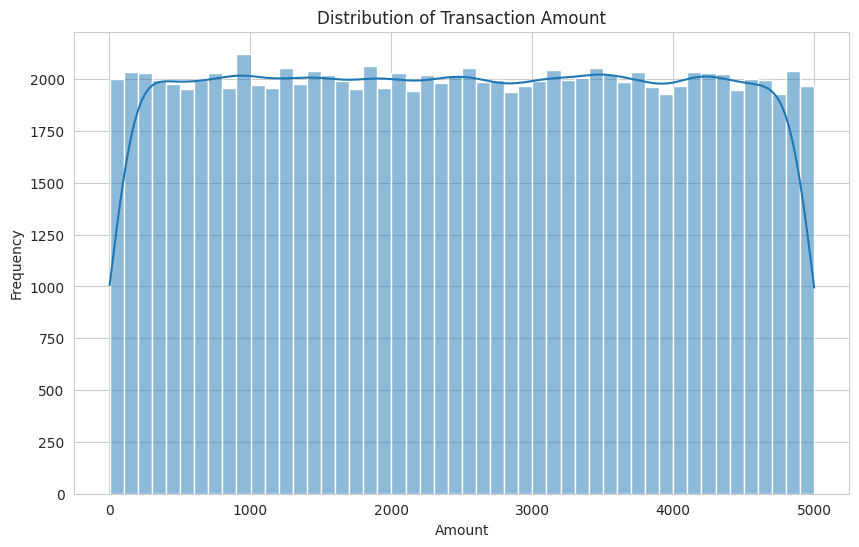

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Distribution of 'Amount'
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

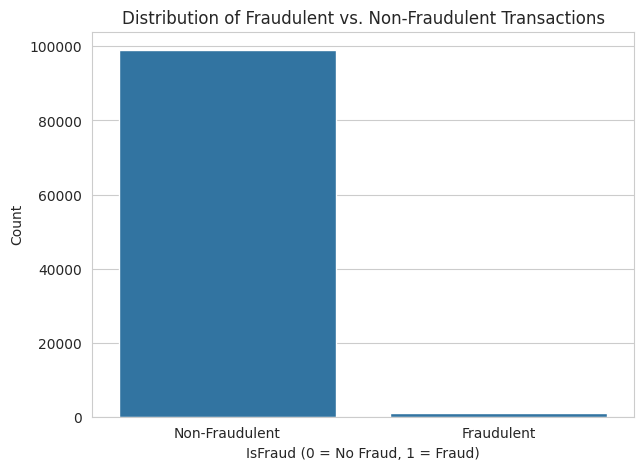

In [ ]:
# Distribution of 'IsFraud'
plt.figure(figsize=(7, 5))
sns.countplot(x='IsFraud', data=df)
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('IsFraud (0 = No Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

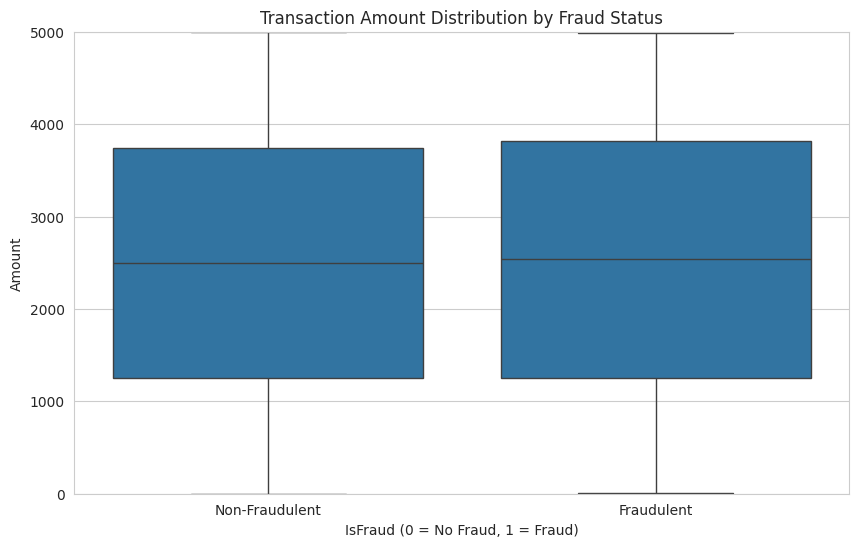

In [ ]:
# Box plot of 'Amount' by 'IsFraud'
plt.figure(figsize=(10, 6))
sns.boxplot(x='IsFraud', y='Amount', data=df)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('IsFraud (0 = No Fraud, 1 = Fraud)')
plt.ylabel('Amount')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])
plt.ylim(0, 5000) # Limit y-axis for better visualization if there are extreme outliers
plt.show()

In [ ]:
# One-hot encode 'TransactionType' and 'Location'
df_encoded = pd.get_dummies(df, columns=['TransactionType', 'Location'], drop_first=True)

# Display the first few rows of the encoded DataFrame and its info
print("\nDataFrame Info after one-hot encoding:")
df_encoded.info()
print("\nFirst 5 rows of the encoded DataFrame:")
display(df_encoded.head())


DataFrame Info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   TransactionID           100000 non-null  int64         
 1   TransactionDate         100000 non-null  datetime64[ns]
 2   Amount                  100000 non-null  float64       
 3   MerchantID              100000 non-null  int64         
 4   IsFraud                 100000 non-null  int64         
 5   TransactionHour         100000 non-null  int32         
 6   TransactionDayOfWeek    100000 non-null  int32         
 7   TransactionMonth        100000 non-null  int32         
 8   TransactionType_refund  100000 non-null  bool          
 9   Location_Dallas         100000 non-null  bool          
 10  Location_Houston        100000 non-null  bool          
 11  Location_Los Angeles    100000 non-null  bool       

,TransactionID,TransactionDate,Amount,MerchantID,IsFraud,TransactionHour,TransactionDayOfWeek,TransactionMonth,TransactionType_refund,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,1,2024-04-03 14:15:35.462794,4189.27,688,0,14,2,4,True,False,False,False,False,False,False,True,False,False
1,2,2024-03-19 13:20:35.462824,2659.71,109,0,13,1,3,True,True,False,False,False,False,False,False,False,False
2,3,2024-01-08 10:08:35.462834,784.00,394,0,10,0,1,False,False,False,False,True,False,False,False,False,False
3,4,2024-04-13 23:50:35.462850,3514.40,944,0,23,5,4,False,False,False,False,False,True,False,False,False,False
4,5,2024-07-12 18:51:35.462858,369.07,475,0,18,4,7,False,False,False,False,False,False,True,False,False,False


In [ ]:
# Drop irrelevant columns for modeling
X = df_encoded.drop(columns=['TransactionID', 'TransactionDate', 'IsFraud'])
y = df_encoded['IsFraud']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\nFirst 5 rows of features (X):")
display(X.head())

Shape of features (X): (100000, 15)
Shape of target (y): (100000,)

First 5 rows of features (X):


,Amount,MerchantID,TransactionHour,TransactionDayOfWeek,TransactionMonth,TransactionType_refund,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,4189.27,688,14,2,4,True,False,False,False,False,False,False,True,False,False
1,2659.71,109,13,1,3,True,True,False,False,False,False,False,False,False,False
2,784.00,394,10,0,1,False,False,False,False,True,False,False,False,False,False
3,3514.40,944,23,5,4,False,False,False,False,False,True,False,False,False,False
4,369.07,475,18,4,7,False,False,False,False,False,False,True,False,False,False


### 1. Split Data into Training and Testing Sets

We'll use `train_test_split` from `sklearn` to divide our features `X` and target `y` into training and testing sets. This ensures we evaluate our models on data they haven't seen during training.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check the fraud distribution in train and test sets
print("\nFraud distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nFraud distribution in test set:")
print(y_test.value_counts(normalize=True))

X_train shape: (80000, 15)
X_test shape: (20000, 15)
y_train shape: (80000,)
y_test shape: (20000,)

Fraud distribution in training set:
IsFraud
0    0.99
1    0.01
Name: proportion, dtype: float64

Fraud distribution in test set:
IsFraud
0    0.99
1    0.01
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# Ensure X and y are defined from previous cells
# This line ensures X_train is defined if the preceding cell (04f68736) was not run.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("First 5 rows of X_train:")
display(X_train.head())

NameError: name 'X' is not defined

### 2. Model Training and Evaluation

Now, let's train a few common classification models and evaluate their performance. We'll use:

*   **Logistic Regression**: A simple yet effective baseline model.
*   **Random Forest Classifier**: An ensemble method known for its robustness.
*   **LightGBM Classifier**: A gradient boosting framework that is fast and efficient.

For evaluation, we'll look at `accuracy` (as requested) and also `precision`, `recall`, and `f1-score` from a classification report, which are crucial for imbalanced datasets like fraud detection.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Calculate class weights for imbalance handling
# This gives a higher weight to the minority class (fraud)
class_weights = {0: 1, 1: (len(y_train) - y_train.sum()) / y_train.sum()}
print(f"Calculated Class Weights: {class_weights}")

# Define models with class weights
models_weighted = {
    'Logistic Regression (Weighted)': LogisticRegression(random_state=42, solver='liblinear', class_weight=class_weights),
    'Random Forest (Weighted)': RandomForestClassifier(random_state=42, n_estimators=100, class_weight=class_weights),
    'LightGBM (Weighted)': lgb.LGBMClassifier(random_state=42, n_estimators=100, is_unbalance=True) # LightGBM's way to handle imbalance
}

results_weighted = {}

print("\n--- Training Models with Class Weights ---")
for name, model in models_weighted.items():
    print(f"\n--- Training {name} ---")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results_weighted[name] = {
        'accuracy': accuracy,
        'report': report
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

Calculated Class Weights: {0: 1, 1: np.float64(99.0)}

--- Training Models with Class Weights ---

--- Training Logistic Regression (Weighted) ---
Accuracy: 0.5360
              precision    recall  f1-score   support

           0       0.99      0.54      0.70     19800
           1       0.01      0.41      0.02       200

    accuracy                           0.54     20000
   macro avg       0.50      0.48      0.36     20000
weighted avg       0.98      0.54      0.69     20000


--- Training Random Forest (Weighted) ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Accuracy: 0.9900
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19800
           1       0.00      0.00      0.00       200

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.99     20000


--- Training LightGBM (Weighted) ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 800, number of negative: 79200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001879 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 574
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010000 -> initscore=-4.595120
[LightGBM] [Info] Start training from

### 3. Compare Models and Select the Best

Let's summarize the accuracy scores to easily compare the models.

In [ ]:
print("\n--- Model Comparison (Accuracy) with Class Weights ---")
for name, metrics in results_weighted.items():
    print(f"{name}: Accuracy = {metrics['accuracy']:.4f}")

# Determine the best model based on accuracy with class weights
best_model_name_weighted = max(results_weighted, key=lambda k: results_weighted[k]['accuracy'])
best_accuracy_weighted = results_weighted[best_model_name_weighted]['accuracy']

print(f"\nBased on accuracy with class weights, the best model is: {best_model_name_weighted} with an accuracy of {best_accuracy_weighted:.4f}")

print(f"\nClassification Report for {best_model_name_weighted} (with Class Weights):")
# Re-predict with the best weighted model to get the classification report correctly
best_model_instance_weighted = models_weighted[best_model_name_weighted]
print(classification_report(y_test, best_model_instance_weighted.predict(X_test)))


--- Model Comparison (Accuracy) with Class Weights ---
Logistic Regression (Weighted): Accuracy = 0.5360
Random Forest (Weighted): Accuracy = 0.9900
LightGBM (Weighted): Accuracy = 0.8307

Based on accuracy with class weights, the best model is: Random Forest (Weighted) with an accuracy of 0.9900

Classification Report for Random Forest (Weighted) (with Class Weights):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19800
           1       0.00      0.00      0.00       200

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.99     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 4. Save the Best Model

Let's save the best performing model, `Random Forest (Weighted)`, to a file using `pickle` for future use. This allows us to deploy or use the model without having to retrain it.

In [ ]:
import pickle

# Get the best model instance from the models_weighted dictionary
best_model_to_save = models_weighted[best_model_name_weighted]

# Define the filename
model_filename = 'Model.pkl'

# Save the model to the file
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_to_save, file)

print(f"The best model '{best_model_name_weighted}' has been saved as '{model_filename}'.")

The best model 'Random Forest (Weighted)' has been saved as 'Model.pkl'.
